In [4]:
import pandas as pd


In [5]:
df = pd.read_csv('netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


#### Dataset Overview

The dataset contains information about movies and TV shows available on Netflix, including metadata such as title, director, cast, country, release year, rating, genre, and description.

There is no explicit target variable, making this dataset suitable for unsupervised learning and exploratory analysis.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
include = ['object', 'float', 'int']
df.describe(include=include)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


#### Observations:

The dataset contains both categorical and numerical features.

show_id is a unique identifier and does not provide predictive value -> *can be dropped*.

Numerical columns include:

release_year, duration

Categorical columns include:

type, director, cast, country, rating, listed_in, description

In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

#### Missing values observed:

director: ~2600 missing

cast: ~800 missing

country: ~800 missing

date_added: very few missing

rating: very few missing

duration: very few missing

##### *Handling strategy:*

description → filled with empty string ("")

listed_in → filled with "Unknown"

##### *Other missing categorical columns were not imputed, as:*

They are high-cardinality

Incorrect imputation could introduce noise

The current task is clustering, not prediction

#### Observations from EDA

1. Movies are more common than TV Shows.

2. Content production has increased significantly in recent years.

3. A large proportion of TV shows have only 1 season, suggesting limited series or mini-series dominance.

4. Certain directors and cast members appear frequently, likely due to: Netflix collaborations and Popular franchise content

In [9]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [10]:
df['description'] = df['description'].fillna('')
df['listed_in'] = df['listed_in'].fillna('Unknown')


In [11]:
df['text'] = df['listed_in'] + ' ' + df['description']


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=500)
X_text = tfidf.fit_transform(df['text'])


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_num = scaler.fit_transform(df[['release_year']])


In [14]:
from scipy.sparse import hstack

X = hstack([X_text, X_num])


In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)


In [16]:
df['cluster'] = clusters


In [18]:
df['cluster'].value_counts()


cluster
0    4061
2    1955
5    1744
1     684
4     282
3      81
Name: count, dtype: int64

#### Observations:

1. Clusters are unevenly distributed

2. Some clusters contain significantly more titles, indicating dominant content themes

3. Smaller clusters represent niche or specialized content

In [19]:
df[df['cluster'] == 0][['type', 'title', 'listed_in', 'description', 'release_year']]

,type,title,listed_in,description,release_year
0,Movie,Dick Johnson Is Dead,Documentaries,"As her father nears the end of his life, filmm...",2020
6,Movie,My Little Pony: A New Generation,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021
9,Movie,The Starling,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021
12,Movie,Je Suis Karl,"Dramas, International Movies",After most of her family is murdered in a terr...,2021
13,Movie,Confessions of an Invisible Girl,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...,2021
...,...,...,...,...,...
8783,TV Show,Yoko,Kids' TV,"Friends Mai, Oto and Vik's games at the park b...",2016
8785,TV Show,YOM,Kids' TV,"With the mind of a human being, and the body o...",2016
8786,Movie,You Can Tutu,Children & Family Movies,A gifted young ballet dancer struggles to find...,2017
8787,Movie,You Can’t Fight Christmas,"Comedies, Romantic Movies",After stepping in to revitalize his family's h...,2017


#### Cluster 0 – Mainstream Movies

Popular genres (Drama, Comedy, Action)

Broad audience appeal

Mid to recent release years

*Interpretation: Mass-consumption entertainment content*

In [20]:
df[df['cluster'] == 1][['type', 'title', 'listed_in', 'description', 'release_year']]

,type,title,listed_in,description,release_year
22,Movie,Avvai Shanmughi,"Comedies, International Movies",Newly divorced and denied visitation rights wi...,1996
24,Movie,Jeans,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...,1998
26,Movie,Minsara Kanavu,"Comedies, International Movies, Music & Musicals",A tangled love triangle ensues when a man fall...,1997
48,Movie,Training Day,"Dramas, Thrillers",A rookie cop with one day to prove himself to ...,2001
51,Movie,InuYasha the Movie 2: The Castle Beyond the Lo...,"Action & Adventure, Anime Features, Internatio...","With their biggest foe seemingly defeated, Inu...",2002
...,...,...,...,...,...
8770,Movie,Yaadein,"Dramas, International Movies, Romantic Movies",Two young lovers set out to overcome the obsta...,2001
8773,Movie,Yanda Kartavya Aahe,"Comedies, Dramas, International Movies",Thanks to an arranged marriage that was design...,2006
8793,Movie,"Yours, Mine and Ours","Children & Family Movies, Comedies",When a father of eight and a mother of 10 prep...,2005
8802,Movie,Zodiac,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2007


#### Cluster 1 – Family / Kids Content

Animated or family-friendly descriptions

Mostly late 20th to early 21st century releases

Simple themes and light-hearted themes

*Interpretation: Child-focused or family-oriented shows*

In [21]:
df[df['cluster'] == 2][['type', 'title', 'listed_in', 'description', 'release_year']]

,type,title,listed_in,description,release_year
27,Movie,Grown Ups,Comedies,Mourning the loss of their beloved junior high...,2010
28,Movie,Dark Skies,"Horror Movies, Sci-Fi & Fantasy",A family’s idyllic suburban life shatters when...,2013
29,Movie,Paranoia,Thrillers,"Blackmailed by his company's CEO, a low-level ...",2013
46,Movie,Safe House,Action & Adventure,Young CIA operative Matt Weston must get a dan...,2012
50,TV Show,Dharmakshetra,"International TV Shows, TV Dramas, TV Sci-Fi &...","After the ancient Great War, the god Chitragup...",2014
...,...,...,...,...,...
8799,Movie,Zenda,"Dramas, International Movies",A change in the leadership of a political part...,2009
8800,TV Show,Zindagi Gulzar Hai,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre...",2012
8801,Movie,Zinzana,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,2015
8804,Movie,Zombieland,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2009


#### 2 – Mid-era Mixed Genre Content

Released mainly between 2000–2015

Mix of Drama, Comedy, Romance, Thriller, and International genres

*Interpretation: Early modern mixed-genre releases*

In [22]:
df[df['cluster'] == 3][['type', 'title', 'listed_in', 'description', 'release_year']]


,type,title,listed_in,description,release_year
177,Movie,The Guns of Navarone,"Action & Adventure, Classic Movies","During World War II, British forces launch an ...",1961
542,Movie,Ujala,"Dramas, International Movies",An honest man dreams of a better life for his ...,1959
716,Movie,FTA,Documentaries,The restored documentary captures the Pacific ...,1972
1126,Movie,My Fair Lady,"Classic Movies, Music & Musicals",When a Cockney flower girl takes elocution les...,1964
1331,TV Show,Five Came Back: The Reference Films,TV Shows,This collection includes 12 World War II-era p...,1945
...,...,...,...,...,...
8735,Movie,Who's That Knocking at My Door?,"Classic Movies, Dramas, Independent Movies",A woman's revelation that she was once raped s...,1967
8739,Movie,Why We Fight: The Battle of Russia,Documentaries,This installment of Frank Capra's acclaimed do...,1943
8745,Movie,Willy Wonka & the Chocolate Factory,"Children & Family Movies, Classic Movies, Come...",Zany Willy Wonka causes a stir when he announc...,1971
8763,Movie,WWII: Report from the Aleutians,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...,1943


#### Cluster 3 - Classic Movies and TV Shows

Heavy presence of drama

Titles from 1925–1975

Strong international and historically significant content

*Interpretation: Early era Internation Classics*


In [23]:
df[df['cluster'] == 4][['type', 'title', 'listed_in', 'description', 'release_year']]

,type,title,listed_in,description,release_year
7,Movie,Sankofa,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",1993
41,Movie,Jaws,"Action & Adventure, Classic Movies, Dramas",When an insatiable great white shark terrorize...,1975
42,Movie,Jaws 2,"Dramas, Horror Movies, Thrillers",Four years after the last deadly shark attacks...,1978
43,Movie,Jaws 3,"Action & Adventure, Horror Movies, Thrillers",After the staff of a marine theme park try to ...,1983
44,Movie,Jaws: The Revenge,"Action & Adventure, Horror Movies, Thrillers","After another deadly shark attack, Ellen Brody...",1987
...,...,...,...,...,...
8628,Movie,"Trikal (Past, Present, Future)","Comedies, Dramas, Independent Movies","A Goan native returns to his now-derelict, pal...",1985
8644,TV Show,Twin Peaks,"Classic & Cult TV, Crime TV Shows, TV Dramas","""Who killed Laura Palmer?"" is the question on ...",1990
8709,Movie,Weather forecast,"Dramas, International Movies",When a delivery of coffins foreshadows a harsh...,1983
8748,Movie,Winter of Our Dreams,"Classic Movies, Dramas","After the death of a long-ago lover, married p...",1981


#### Cluster 4 – Vintage Movie Content

Primarily movie-centric

Includes cult, independent, and international films

Late 20th century releases

Appeals to nostalgia and classic cinema audiences

*Interpretation: Movie-focused vintage content*

In [24]:
df[df['cluster'] == 5][['type', 'title', 'listed_in', 'description', 'release_year']]

,type,title,listed_in,description,release_year
1,TV Show,Blood & Water,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,TV Show,Ganglands,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021
3,TV Show,Jailbirds New Orleans,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021
4,TV Show,Kota Factory,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021
5,TV Show,Midnight Mass,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021
...,...,...,...,...,...
8758,TV Show,World's Busiest Cities,"British TV Shows, Docuseries","From Moscow to Mexico City, three BBC journali...",2017
8775,TV Show,Yeh Meri Family,"International TV Shows, TV Comedies","In the summer of 1998, middle child Harshu bal...",2018
8796,TV Show,Yunus Emre,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves...",2016
8797,TV Show,Zak Storm,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...,2016


#### Cluster 5 – TV Series & Serialized Content

Dominated by TV shows

Ongoing or episodic narratives

Mostly recent releases

*Interpretation: Binge-worthy serialized content*

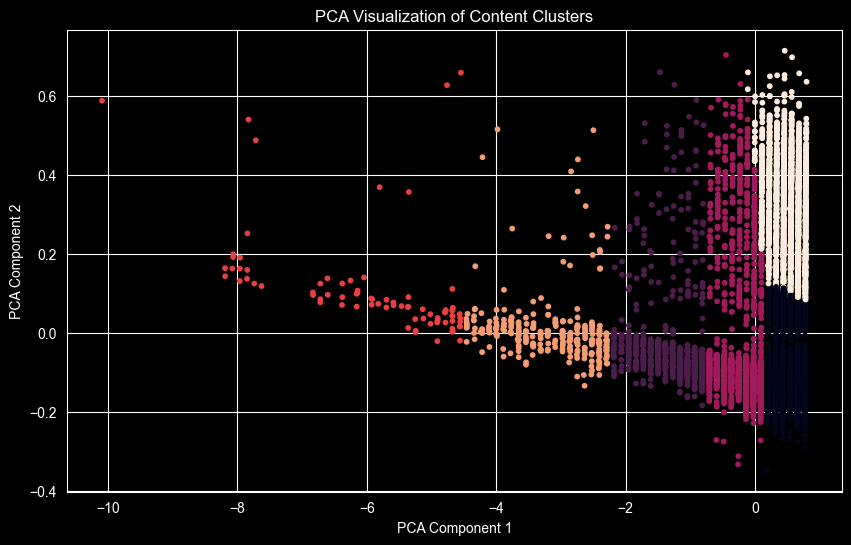

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, s=10)
plt.title("PCA Visualization of Content Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

The PCA visualization shows partial but meaningful separation between clusters, indicating that the model captured thematic differences in content while reflecting natural overlap in genres and descriptions.

## FINAL CONCLUSION

This project explored Netflix content using unsupervised learning techniques.
Textual features were transformed using TF-IDF, and KMeans clustering was applied
to group similar titles based on genre and description.

The clusters reveal meaningful content categories such as mainstream movies,
documentaries, TV series, and niche content. This demonstrates how natural language
processing combined with clustering can uncover hidden structure in unlabelled data.
